# Stage 3 — Make edge physics measurable

- Gabriel Wendell Celestino Rocha
---

This notebook uses only the tested `qhe` package. It connects the Stage-2 periodic Chern calculation to a finite x-open/y-periodic ribbon through explicit edge participation and side-resolved reference-energy crossings.

In [1]:
import numpy as np
from qhe.boundary import analyze_bulk_boundary_correspondence
from qhe.models import HarperHofstadterParameters
from qhe.viz import plot_bulk_boundary_spectrum, plot_crossing_profiles

params = HarperHofstadterParameters(p=1, q=3, tx=1.0, ty=1.0)

## Compute bulk gaps and a ribbon spectrum

The `edge_threshold` is part of the documented numerical protocol: an accepted crossing must have at least this fraction of probability inside the two edge strips.

In [2]:
analysis = analyze_bulk_boundary_correspondence(
    params,
    bulk_nkx = 41,
    bulk_nky = 41,
    ribbon_lx = 48,
    ribbon_nky = 181,
    edge_width = 4,
    edge_threshold = 0.70,
)

print("Band Chern numbers:", np.rint(analysis.topology.fhs.chern_numbers).astype(int))
for summary in analysis.crossing_summaries:
    print(
        f"> gap {summary.gap.index + 1}: C_gap={summary.gap.gap_chern_number:+d}, "
        f"left={summary.left_oriented_crossing_count:+d}, "
        f"right={summary.right_oriented_crossing_count:+d}"
    )

Band Chern numbers: [-1  2 -1]
> gap 1: C_gap=-1, left=-1, right=+1
> gap 2: C_gap=+1, left=+1, right=-1


## Edge-participation spectrum

Marker intensity encodes total edge participation. Triangles mark accepted midgap crossings; their direction indicates the sign of the local branch slope.

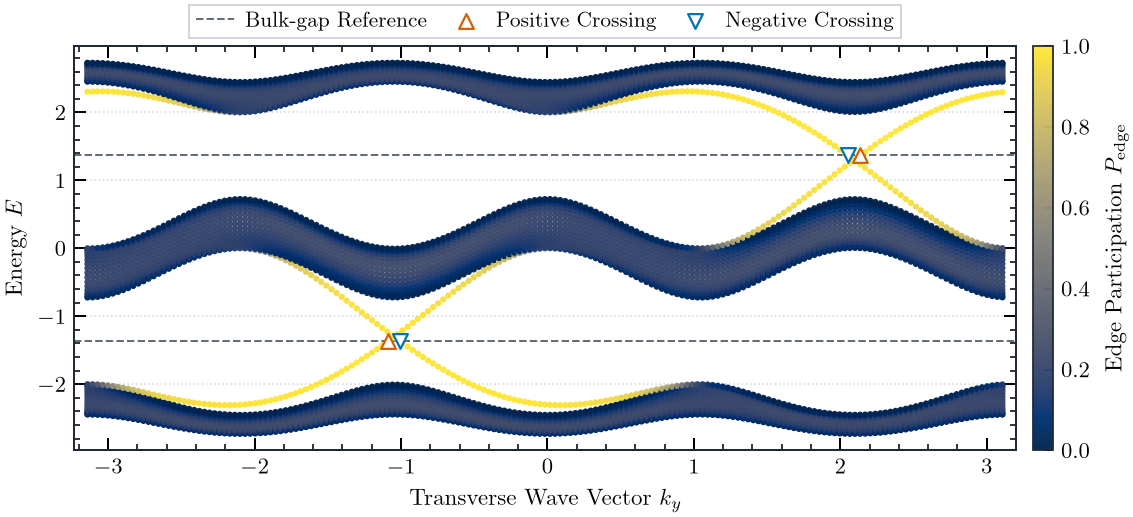

In [3]:
figure, ax = plot_bulk_boundary_spectrum(analysis)

## Representative left and right edge profiles

The profiles are selected from the detected crossings, not manually guessed from the plot.

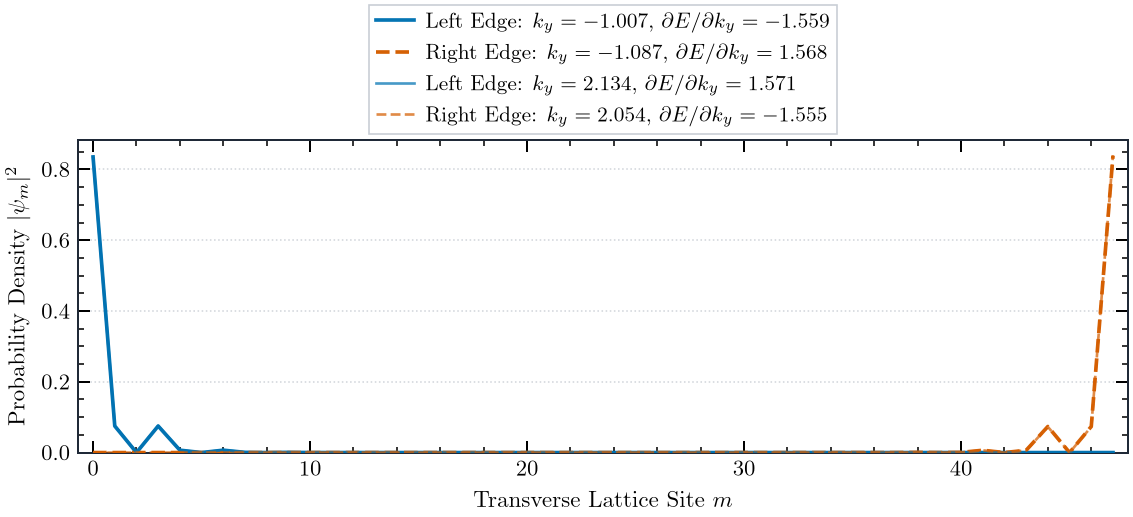

In [4]:
selected = tuple(
    crossing
    for summary in analysis.crossing_summaries
    for crossing in (*summary.left_crossings[:1], *summary.right_crossings[:1])
)
figure, ax = plot_crossing_profiles(analysis.ribbon, selected)

## Interpretation

For the frozen convention, the bulk gap Chern sequence is `(-1, +1)`. The left-edge oriented crossing counts reproduce this sequence, while the right-edge counts have the opposite sign because the boundaries face opposite directions. This is a finite-ribbon numerical diagnostic of bulk-boundary correspondence; it is not yet a time-domain demonstration of chiral packet transport.

---